In [12]:
import pandas as pd
df = pd.read_csv("../data/raw/VEHICULOS_INV_EN_UN_ACCIDENTE.csv", sep=';' )
df.head()

C:\Users\caror\AppData\Local\Temp\ipykernel_416\2571131681.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/VEHICULOS_INV_EN_UN_ACCIDENTE.csv", sep=';' )


,MARCA_VEHICULO,MODELO_VEHICULO,TIPO_VEHICULO,EDAD_VEHICULO,FECHA_ACCIDENTE,GRAVEDAD_ACCIDENTE,DEPARTAMENTO_ACCIDENTE,MUNICIPIO_ACCIDENTE,AUTORIDAD_DE_TRANSITO
0,HONDA,2017,MOTOCICLETA,9.0,dic-25,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
1,CHEVROLET,2007,CAMION,20.0,dic-25,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
2,JEEP,2017,CAMPERO,9.0,dic-25,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
3,CHEVROLET,2023,CAMIONETA,2.0,dic-25,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
4,HONDA,2026,MOTOCICLETA,1.0,dic-25,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA


In [13]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406540 entries, 0 to 406539
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   MARCA_VEHICULO          406496 non-null  object
 1   MODELO_VEHICULO         406540 non-null  int64 
 2   TIPO_VEHICULO           406540 non-null  object
 3   EDAD_VEHICULO           406520 non-null  object
 4   FECHA_ACCIDENTE         406540 non-null  object
 5   GRAVEDAD_ACCIDENTE      406540 non-null  object
 6   DEPARTAMENTO_ACCIDENTE  406540 non-null  object
 7   MUNICIPIO_ACCIDENTE     406540 non-null  object
 8   AUTORIDAD_DE_TRANSITO   406540 non-null  object
dtypes: int64(1), object(8)
memory usage: 27.9+ MB


In [14]:
df.describe(include='all')

,MARCA_VEHICULO,MODELO_VEHICULO,TIPO_VEHICULO,EDAD_VEHICULO,FECHA_ACCIDENTE,GRAVEDAD_ACCIDENTE,DEPARTAMENTO_ACCIDENTE,MUNICIPIO_ACCIDENTE,AUTORIDAD_DE_TRANSITO
count,406496,406540.000000,406540,406520.0,406540,406540,406540,406540,406540
unique,360,NaN,28,165.0,50,2,31,639,232
top,BAJAJ,NaN,MOTOCICLETA,4.0,jul-24,CON HERIDOS,ANTIOQUIA,MEDELLIN,STRIA DE TTOyTTE MEDELLIN
freq,53036,NaN,229212,33465.0,28794,385881,162012,111105,110742
mean,NaN,2015.587573,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,7.817606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1937.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df.isnull().sum().sort_values(ascending=False)

MARCA_VEHICULO            44
EDAD_VEHICULO             20
MODELO_VEHICULO            0
TIPO_VEHICULO              0
FECHA_ACCIDENTE            0
GRAVEDAD_ACCIDENTE         0
DEPARTAMENTO_ACCIDENTE     0
MUNICIPIO_ACCIDENTE        0
AUTORIDAD_DE_TRANSITO      0
dtype: int64

In [16]:
df['EDAD_VEHICULO'] = pd.to_numeric(df['EDAD_VEHICULO'], errors='coerce')

df['MODELO_VEHICULO'] = pd.to_numeric(df['MODELO_VEHICULO'], errors='coerce')


In [17]:
df.isnull().sum().sort_values(ascending=False)

MARCA_VEHICULO            44
EDAD_VEHICULO             21
MODELO_VEHICULO            0
TIPO_VEHICULO              0
FECHA_ACCIDENTE            0
GRAVEDAD_ACCIDENTE         0
DEPARTAMENTO_ACCIDENTE     0
MUNICIPIO_ACCIDENTE        0
AUTORIDAD_DE_TRANSITO      0
dtype: int64

In [18]:
df['SEVERIDAD'] = df['GRAVEDAD_ACCIDENTE'].apply(
    lambda x: 1 if x == 'CON MUERTOS' else 0
)

In [19]:
df["SEVERIDAD"].value_counts()
df["SEVERIDAD"].value_counts(normalize=True)

SEVERIDAD
0    0.949183
1    0.050817
Name: proportion, dtype: float64

In [20]:
df["TIPO_VEHICULO"].value_counts()
df["DEPARTAMENTO_ACCIDENTE"].value_counts().head(10)
df["MUNICIPIO_ACCIDENTE"].value_counts().head(10)

MUNICIPIO_ACCIDENTE
MEDELLIN        111105
BOGOTA           60350
CALI             30300
BARRANQUILLA     12595
BUCARAMANGA       9277
BELLO             8857
IBAGUE            8069
PEREIRA           7704
CARTAGENA         7550
ITAGUI            6440
Name: count, dtype: int64

## Problemas encontrados

- Dataset desbalanceado
- Valores nulos en EDAD_VEHICULO
- Variables categóricas con muchos valores

In [31]:
df["EDAD_VEHICULO"].describe()

count    406519.000000
mean         10.465449
std           7.461105
min           0.000000
25%           5.000000
50%           9.000000
75%          14.000000
max         126.000000
Name: EDAD_VEHICULO, dtype: float64

In [32]:
for col in df.select_dtypes(include="object").columns:
    print(f"{col}: {df[col].nunique()}")

MARCA_VEHICULO: 360
TIPO_VEHICULO: 28
FECHA_ACCIDENTE: 50
GRAVEDAD_ACCIDENTE: 2
DEPARTAMENTO_ACCIDENTE: 31
MUNICIPIO_ACCIDENTE: 639
AUTORIDAD_DE_TRANSITO: 232


Se identificaron variables categóricas con alta cardinalidad como MUNICIPIO_ACCIDENTE, lo cual puede afectar el rendimiento del modelo y requerir técnicas de agrupación o codificación especial.

<Axes: >

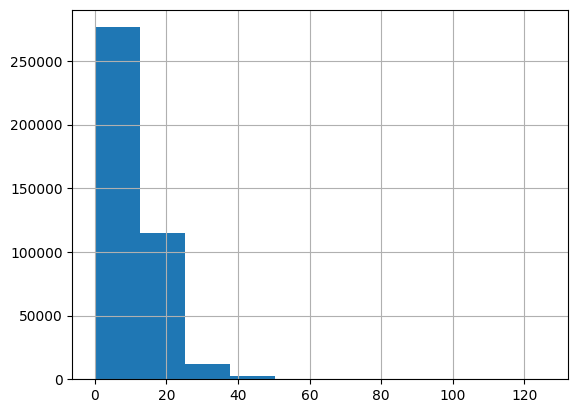

In [33]:
df["EDAD_VEHICULO"].hist()

In [34]:
df["EDAD_VEHICULO"].describe()

count    406519.000000
mean         10.465449
std           7.461105
min           0.000000
25%           5.000000
50%           9.000000
75%          14.000000
max         126.000000
Name: EDAD_VEHICULO, dtype: float64

In [35]:
df.duplicated().sum()

np.int64(147575)

In [36]:
df = df.drop_duplicates()

In [37]:
df[["MODELO_VEHICULO", "EDAD_VEHICULO"]].head()

,MODELO_VEHICULO,EDAD_VEHICULO
0,2017,9.0
1,2007,20.0
2,2017,9.0
3,2023,2.0
4,2026,1.0


In [38]:
df["GRAVEDAD_ACCIDENTE"].value_counts()

GRAVEDAD_ACCIDENTE
CON HERIDOS    238803
CON MUERTOS     20162
Name: count, dtype: int64

El análisis inicial permitió identificar características relevantes del conjunto de datos, evidenciando la presencia de variables categóricas con alta cardinalidad, posibles valores atípicos en variables numéricas y un desbalance significativo en la variable objetivo.

Asimismo, se detectaron valores nulos en algunas variables, aunque en proporciones manejables. Estos hallazgos permiten establecer una base sólida para la siguiente fase de análisis exploratorio, donde se aplicarán técnicas de limpieza, transformación y preparación de datos.